<a href="https://colab.research.google.com/github/simone-cappelletti/ai-sample-projects-library/blob/main/TropicTaste_Inc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificazione di frutti esotici
Dettagli del Progetto:

- **Dataset**: Utilizzo di un dataset contenente varie caratteristiche numeriche di diversi frutti esotici.
- **Algoritmo**: Implementazione dell'algoritmo **K-Nearest Neighbors** (KNN) per la classificazione.
- **Output**: Il modello deve predire correttamente il tipo di frutto basandosi sui dati forniti.


# Requisiti del Progetto
1. Preparazione del Dataset
    - Caricamento e preprocessamento dei dati sui frutti esotici.
    - Gestione di eventuali valori mancanti, normalizzazione e scalatura dei dati.
2. Implementazione del Modello KNN
    - Sviluppo e addestramento del modello KNN.
    - Ottimizzazione dei parametri per migliorare l'accuratezza predittiva.
3. Valutazione delle Performance
    - Utilizzo di tecniche di validazione incrociata per valutare la capacità di generalizzazione del modello.
    - Calcolo delle metriche di performance, come l'accuratezza e l'errore di classificazione.
4. Visualizzazione dei Risultati
    - Creazione di grafici per visualizzare e confrontare le performance del modello.
    - Analisi e interpretazione dei risultati per identificare eventuali aree di miglioramento.

# Dataset
Il [dataset](https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv) contiene le seguenti variabili:

- **Frutto**: Il tipo di frutto. Questa è la variabile di destinazione (target) che vogliamo prevedere.
- **Peso (g)**: Il peso del frutto in grammi. Variabile continua.
- **Diametro medio (mm)**: Il diametro medio del frutto in millimetri. Variabile continua.
- **Lunghezza media (mm)**: La lunghezza media del frutto in millimetri. Variabile continua.
- **Durezza buccia (1-10)**: La durezza della buccia del frutto su una scala da 1 a 10. Variabile continua.
- **Dolcezza (1-10)**: La dolcezza del frutto su una scala da 1 a 10. Variabile continua.

# Implementazione
Inizio con alcuni comandi preliminari per:
- Importazione librerie, funzioni...
- Definizione costanti.
- Importazione del dataset.

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Constants
DATASET_URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv"
SEED = 0
TARGET_FEATURE = "Frutto"
DUREZZA_BUCCIA_FEATURE = "Durezza buccia (1-10)"
DOLCEZZA_FEATURE = "Dolcezza (1-10)"

In [ ]:
# Dataset
df = pd.read_csv(DATASET_URL)

## 1 - Preparazione del Dataset
Analizzo il dataset e faccio dell'analisi esplorativa.

In [ ]:
df.shape

(500, 6)

In [ ]:
df.dtypes

,0
Frutto,object
Peso (g),float64
Diametro medio (mm),float64
Lunghezza media (mm),float64
Durezza buccia (1-10),float64
Dolcezza (1-10),float64


In [ ]:
df.head()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


In [ ]:
df.tail()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
495,Kiwi,40.82,67.52,7.39,7.28,5.56
496,Kiwi,54.65,62.95,7.06,6.47,4.68
497,Kiwi,35.70,71.43,7.64,9.75,4.36
498,Kiwi,30.80,65.23,5.91,7.65,4.13
499,Kiwi,63.71,57.30,7.69,5.30,3.94


In [ ]:
df.sample(5)

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
145,Banana,26.21,190.35,2.47,9.12,1.58
234,Arancia,62.67,84.30,7.99,8.94,4.79
166,Banana,30.57,154.10,2.79,8.89,2.36
315,Uva,20.39,18.57,2.22,9.27,3.80
499,Kiwi,63.71,57.30,7.69,5.30,3.94


In [ ]:
df.describe(include="all")

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500,500.000000,500.000000,500.000000,500.000000,500.000000
unique,5,NaN,NaN,NaN,NaN,NaN
top,Mela,NaN,NaN,NaN,NaN,NaN
freq,100,NaN,NaN,NaN,NaN,NaN
mean,NaN,47.313440,86.573100,5.298620,7.437640,3.593220
std,NaN,26.768797,64.293403,2.641993,1.812548,1.264899
min,NaN,8.570000,7.530000,1.150000,3.070000,1.250000
25%,NaN,24.797500,50.510000,2.672500,6.152500,2.570000
50%,NaN,42.380000,70.450000,5.670000,7.340000,3.535000
75%,NaN,68.080000,88.852500,7.455000,8.615000,4.465000


In [ ]:
print("Valori mancanti per colonna:")
print(df.isna().sum().sort_values(ascending=False))

print("\nRighe duplicate:", df.duplicated().sum())

Valori mancanti per colonna:
Frutto                   0
Peso (g)                 0
Diametro medio (mm)      0
Lunghezza media (mm)     0
Durezza buccia (1-10)    0
Dolcezza (1-10)          0
dtype: int64

Righe duplicate: 0


Dall'analisi possiamo dire che:
- Abbiamo 500 osservazioni in totale e le 5 feature che descrivono i frutti sono, come menzionato nell'introduzione del progetto, tutte di tipo numerico continue (float) pertanto non abbiamo bisogno di feature encoding.
- Dal metodo `describe` capiamo che la variabile target `Frutto` contiene in totale 5 frutti distinti e abbiamo poi una panoramica delle caratteristiche fisiche che descrivono i vari frutti.
- Non abbiamo osservazioni con feature mancanti.
- Non abbiamo osservazioni duplicate.
- Il valore massimo di  `Durezza buccia (1-10)` è di 13, sembra quindi essere fuori scala rispetto a quanto specificato nella descrizione del dataset.
- Anche la `Lunghezza media (mm)` ha valori "strani" come il minimo a 1.15mm. Il fatto poi che il 25esimo percentile sia a 2.67mm indica che non stiamo parlando di poche osservazioni di frutti con una lunghezza molto piccola il che mi fa dubitare di errori di misurazioni, scala o unità di misura. Decido deliberamente in questo caso di non intervenire anche se eventualmente si potrebbe tentare un'imputation e sostituire tali valori con la mediana in base alla classe.

Proseguo verificando effettivamente la scala di  `Durezza buccia (1-10)` (anche di `Dolcezza (1-10)` seppur effettivamente non servirebbe):

In [ ]:
print(f"{DUREZZA_BUCCIA_FEATURE} min: {df[DUREZZA_BUCCIA_FEATURE].min()}")
print(f"{DUREZZA_BUCCIA_FEATURE} max: {df[DUREZZA_BUCCIA_FEATURE].max()}")

print()

print(f"{DOLCEZZA_FEATURE} min: {df[DOLCEZZA_FEATURE].min()}")
print(f"{DOLCEZZA_FEATURE} max: {df[DOLCEZZA_FEATURE].max()}")

Durezza buccia (1-10) min: 3.07
Durezza buccia (1-10) max: 13.72

Dolcezza (1-10) min: 1.25
Dolcezza (1-10) max: 6.95


Capiamo meglio quali osservazioni potrebbero essere anomale:

In [ ]:
outliers = df[(df[DUREZZA_BUCCIA_FEATURE] > 10)]

print(outliers.count())
outliers.sort_values(by=DUREZZA_BUCCIA_FEATURE, ascending=False)

Frutto                   40
Peso (g)                 40
Diametro medio (mm)      40
Lunghezza media (mm)     40
Durezza buccia (1-10)    40
Dolcezza (1-10)          40
dtype: int64


,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
302,Uva,12.81,16.95,1.42,13.72,3.40
175,Banana,24.64,193.76,3.63,13.07,2.08
387,Uva,16.52,22.33,2.37,12.24,3.04
149,Banana,41.99,165.74,2.08,12.15,1.84
384,Uva,14.86,18.27,2.02,12.09,3.39
351,Uva,15.22,18.15,1.75,12.08,5.13
185,Banana,37.56,228.16,2.10,12.04,2.71
373,Uva,16.10,13.33,2.24,11.80,4.71
304,Uva,10.65,20.09,2.02,11.76,4.07
159,Banana,31.48,234.54,2.52,11.75,1.49


Abbiamo 40 osservazioni con valore di `Durezza buccia (1-10)` oltre la scala dichiarata e la maggior parte di esse sono per i frutti `Banana` e `Uva`.

Visto che si parla dell'8% del dataset, non vorrei eliminare tali osservazioni e rischiare di sbilanciare il dataset stesso, soprattutto per i due frutti coinvolti, quindi decido di applicare il clipping:

In [ ]:
df[DUREZZA_BUCCIA_FEATURE] = df[DUREZZA_BUCCIA_FEATURE].clip(upper=10)

print(f"{DUREZZA_BUCCIA_FEATURE} max: {df[DUREZZA_BUCCIA_FEATURE].max()}")

Durezza buccia (1-10) max: 10.0


Proseguo verificando le distribuzioni delle feature:

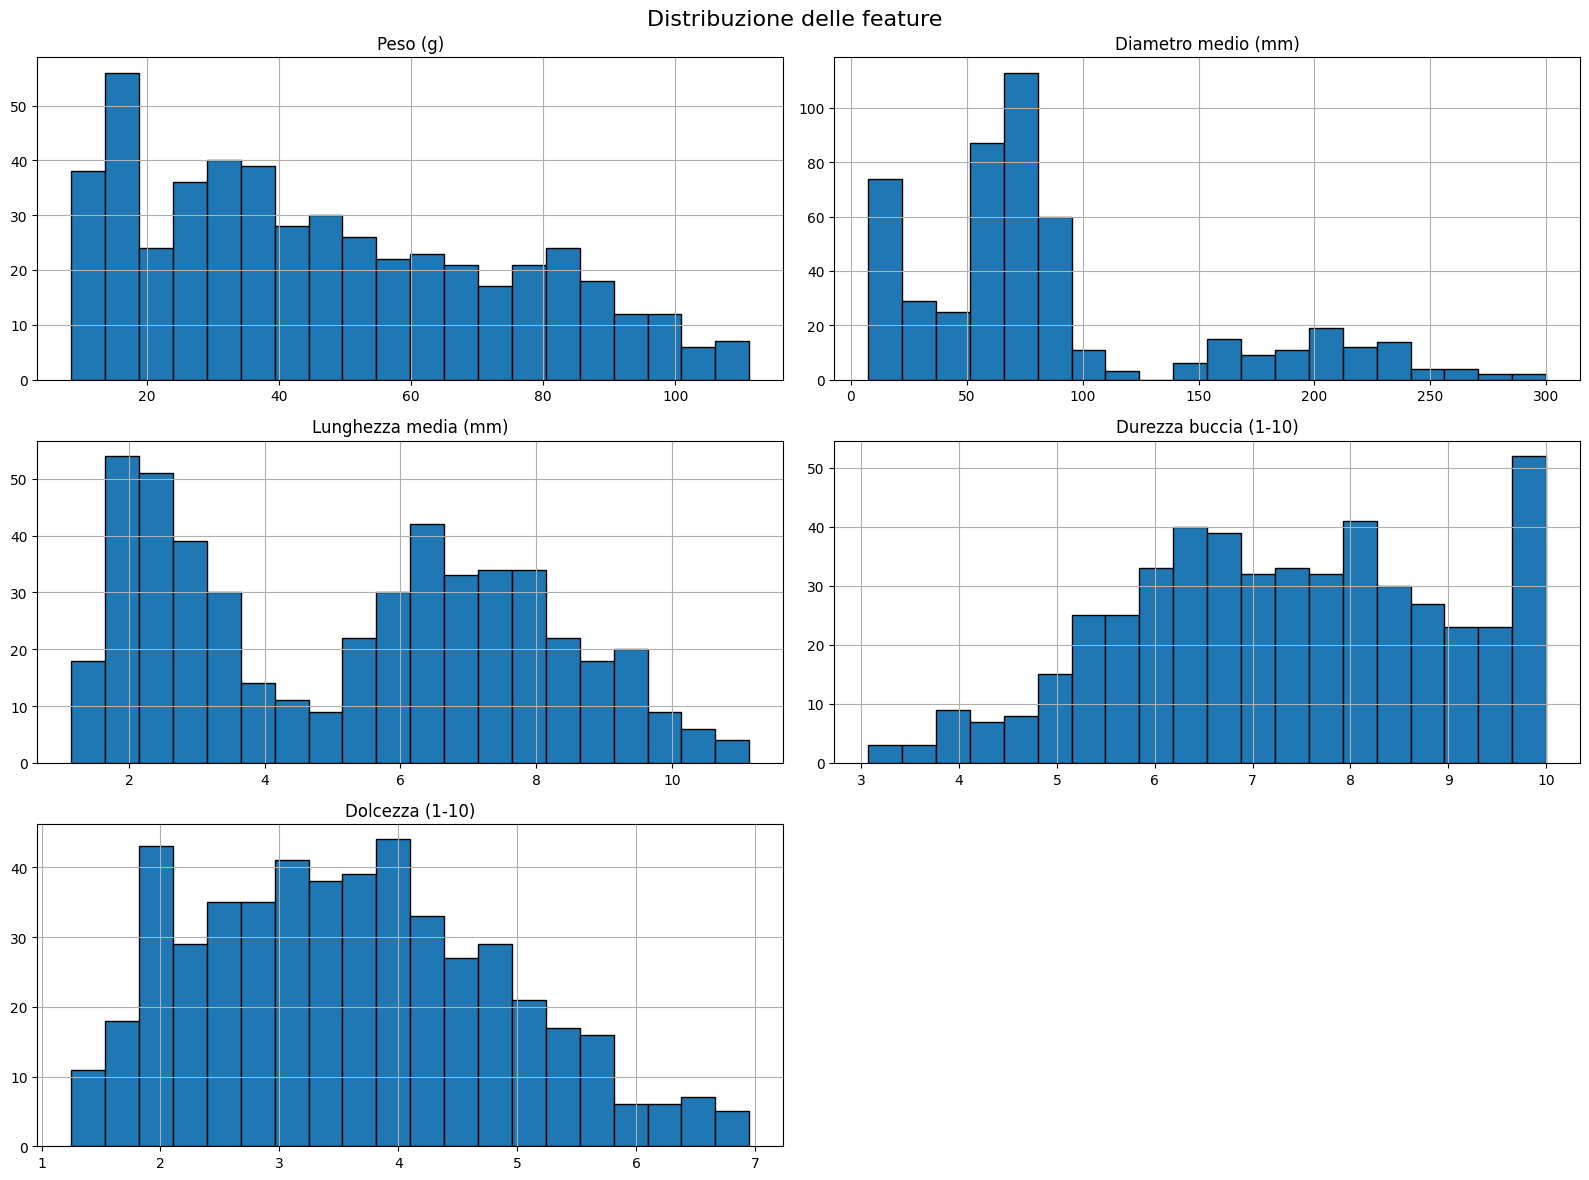

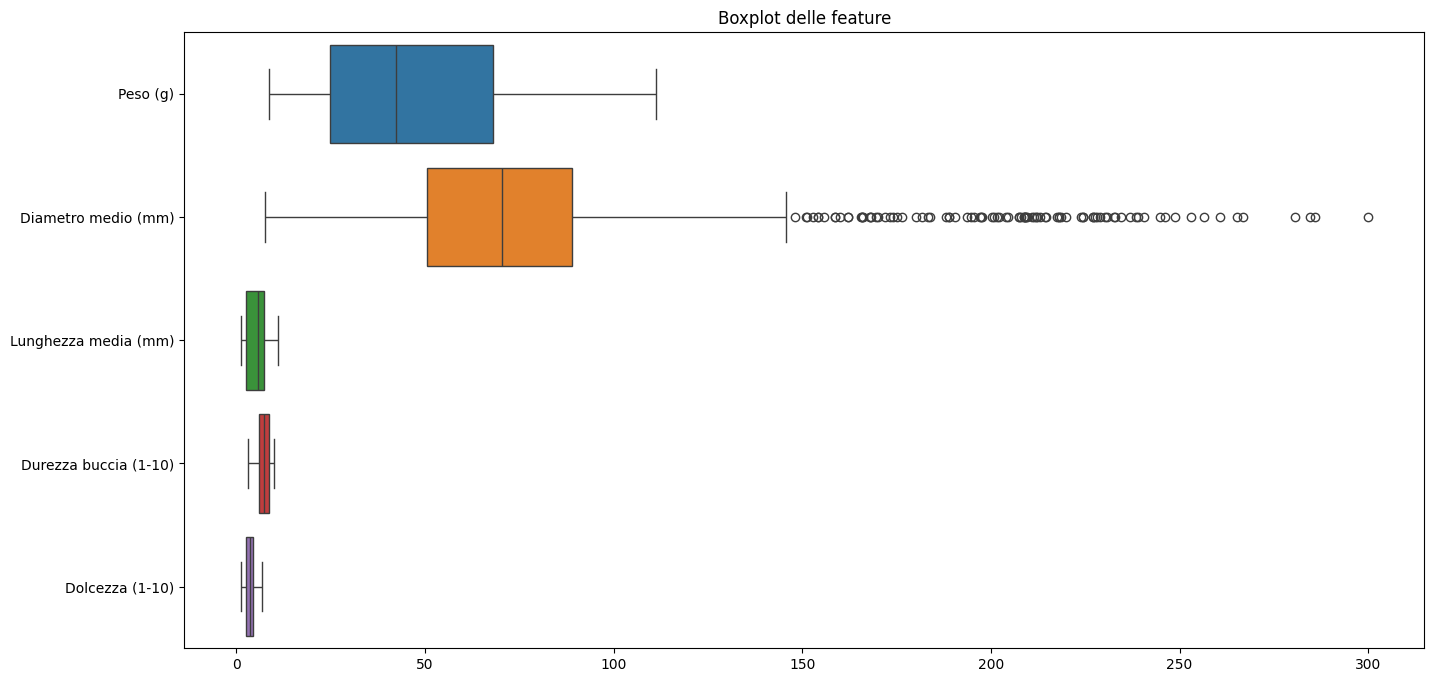

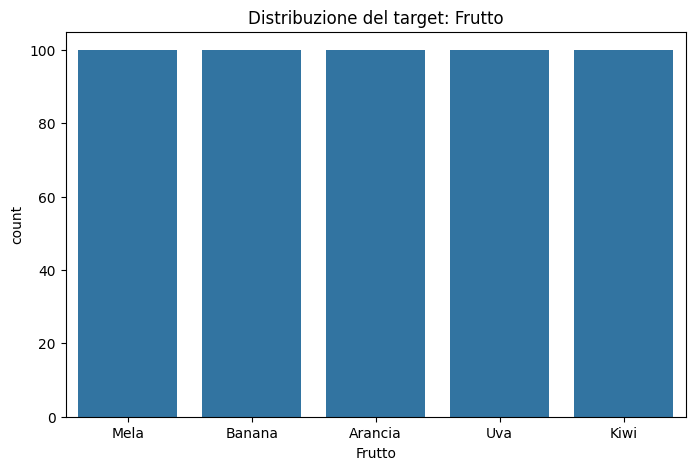

In [ ]:
# Recupero le sole feature numeriche
numeric_columns = df.select_dtypes(include="number").columns.tolist()

# Istogrammi
df[numeric_columns].hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Distribuzione delle feature", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[numeric_columns], orient="h")
plt.title("Boxplot delle feature")
plt.show()

# Distribuzione della variabile target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_FEATURE, order=df[TARGET_FEATURE].value_counts().index)
plt.title(f"Distribuzione del target: {TARGET_FEATURE}")
plt.show()

Quello che noto è che:
- Non ci sono feature particolarmente assimmetriche o con outlier/errori (se non quelli segnalati).
- La distribuzione della feature target indica che le 500 osservazioni sono classificate in maniera bilanciata tra i frutti perché ognuno dei 5 frutti ha esattamente 100 esempi.

Proseguo verificando le feature più correlate tramite matrice di correlazione:

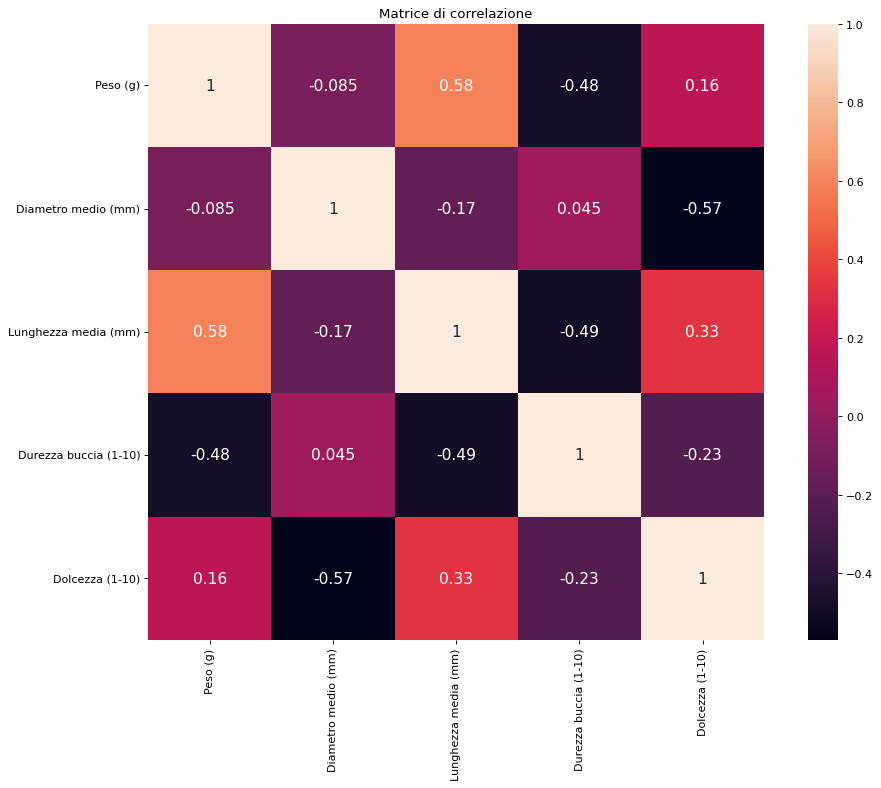

In [ ]:
# Matrice di correlazione
plt.figure(figsize=(14, 10), dpi=80)
sns.heatmap(
  df[numeric_columns].corr(),
  cbar=True,
  square=True,
  yticklabels=numeric_columns,
  xticklabels=numeric_columns,
  annot=True,
  annot_kws={'size':14})
plt.title("Matrice di correlazione")
plt.show()

Tralasciando la feature target che è categorica, noto che non ci sono feature particolarmente correlate in positivo o in negativo ma le più correlate sono:

- "Lunghezza/Peso" in maniera positiva: Intuitivamente è corretto presupporre che frutti fisicamente più lunghi siano anche più pesanti.
- "Durezza buccia/Peso" negativa: Frutti con durezza buccia maggiore sembrano essere mediamente meno pesanti.
- "Dolcezza/Diametro" negativa: Frutti più dolci sembrano avere diametri minori.
- "Durezza buccia/Lunghezza" negativa: Frutti con durezza della buccia maggiore sembrano essere mediamente meno lunghi.

Facciamo anche un'analisi delle distribuzioni delle feature ma stavolta distinguendole per classe, ovvero per frutto:

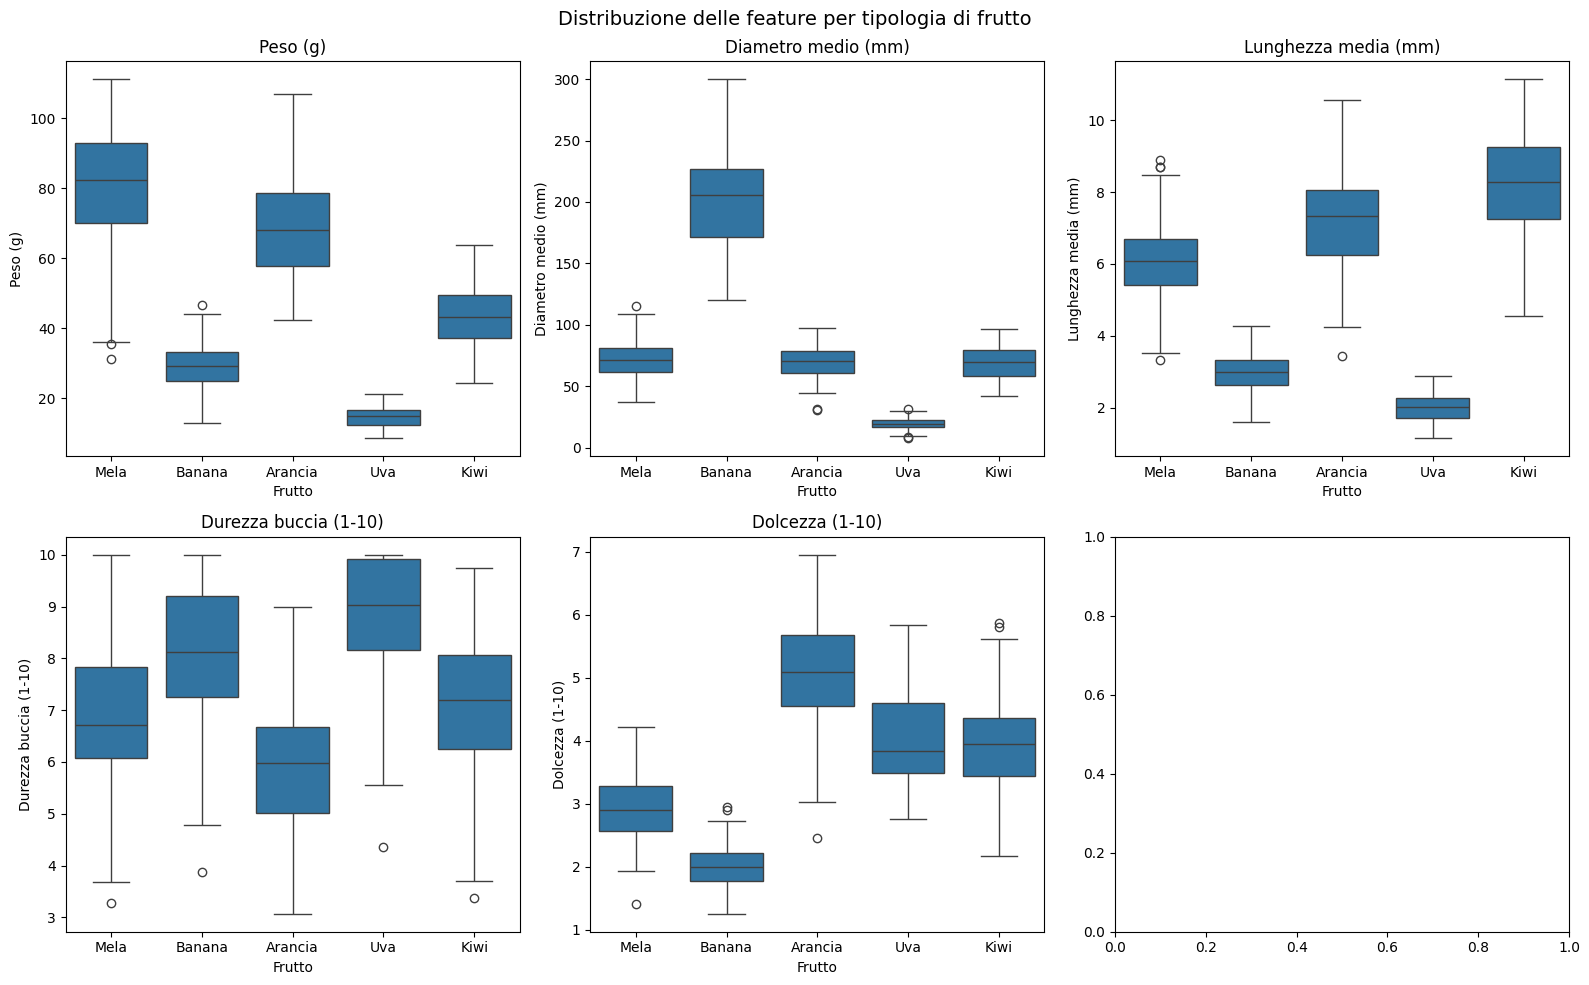

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), numeric_columns):
  sns.boxplot(data=df, x=TARGET_FEATURE, y=col, ax=ax)
  ax.set_title(col)

plt.suptitle("Distribuzione delle feature per tipologia di frutto", fontsize=14)
plt.tight_layout()
plt.show()

È interessante vedere come ogni tipologia di frutto ha le sue peculiarità fisiche. Ad esempio il boxplot del peso per la classe `Mela` è chiaramente differente dallo stesso boxplot ma per la classe `Uva`.

Questo è ottimo per KNN perché ci suggerisce che potrebbe riuscire a classificare in maniera efficace i frutti in quanto ogni tipologia di frutto ha caratteristiche piuttosto 'uniche" (chiaramente si sta parlando solamente di 5 frutti e questo aiuta).

Proseguiamo dunque con un pair plot per mettere in relazione tutte le coppie di feature alla luce però della feature target.

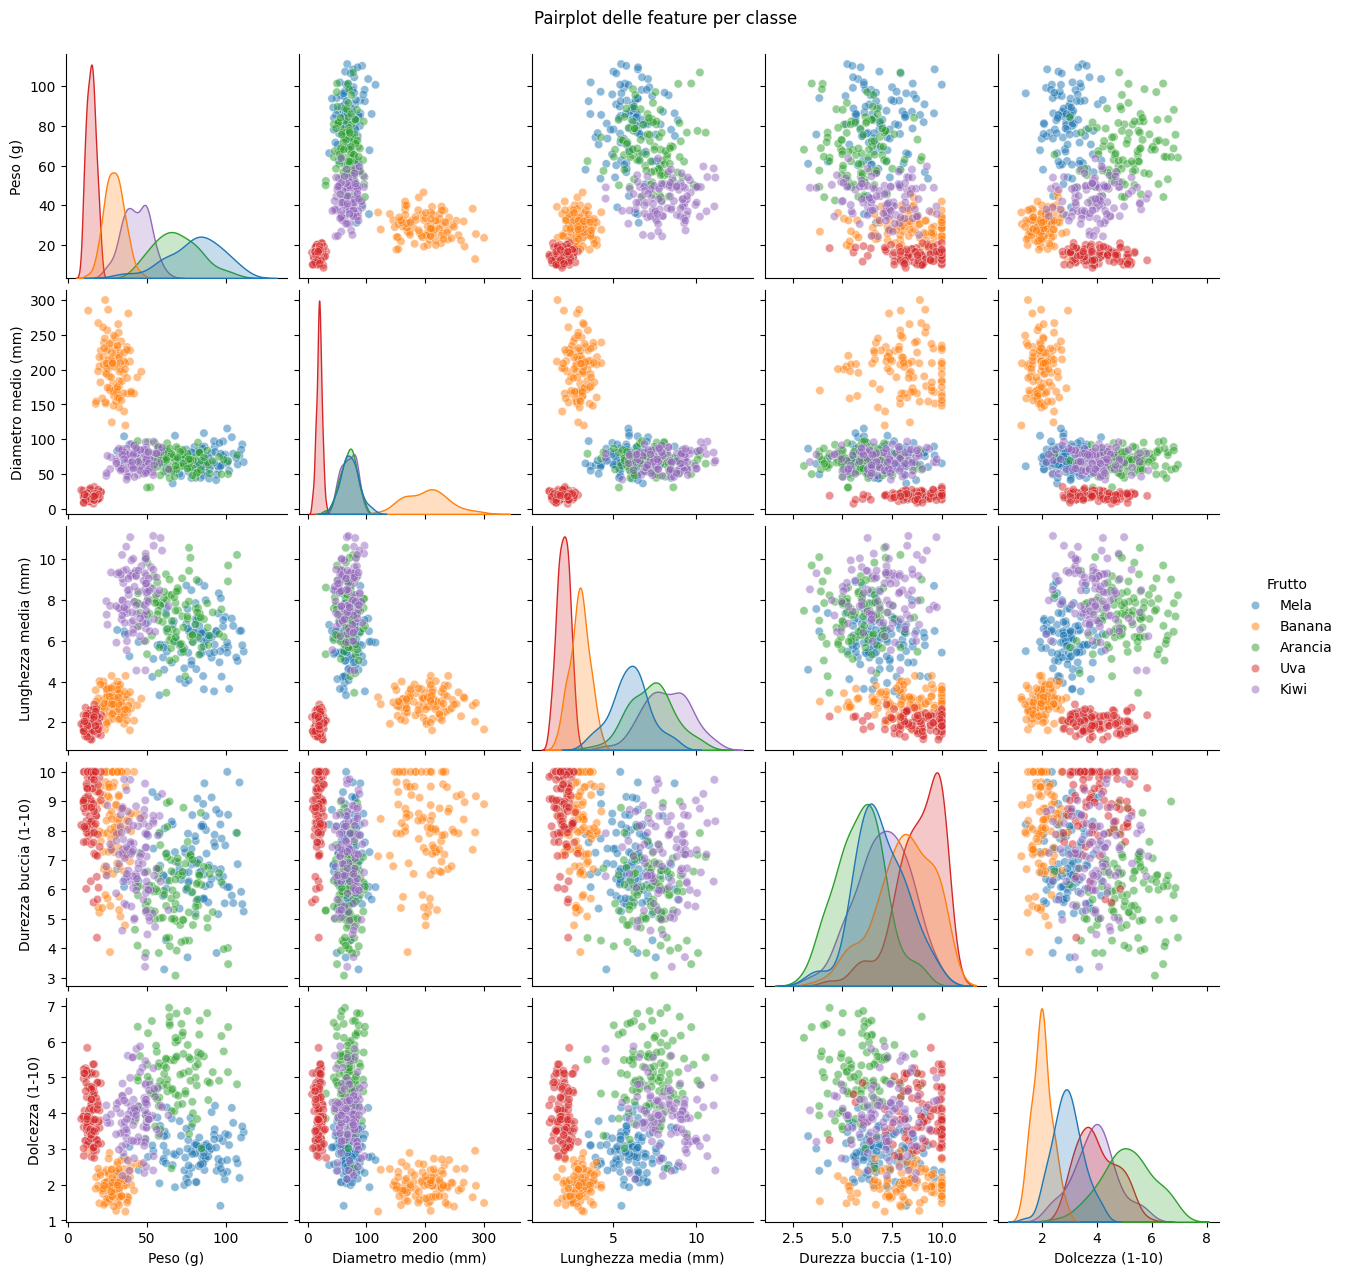

In [ ]:
sns.pairplot(df, hue=TARGET_FEATURE, diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot delle feature per classe", y=1.02)
plt.show()

Ci sono effettivamente alcune zone ben distinguibili e separate dalle altre nei vari grafici adatte all'utilizzo di KNN.

Mi aspetto che la classificazione per `Uva` e `Banana` sia più semplice in quanto sono chiaramente più segregate rispetto altre altre che saranno quindi più difficili da distinguere.

Passiamo al preprocessing:
- Train/Test split classico con 80/20 e mantengo le distribuzioni della classe target nei due dataset bilanciate tramite il parametro `stratify`.
- Preferisco la standardizzazione alla normalizzazione in quanto ho delle anomalie su durezza buccia e lunghezza media ed il rischio con la normalizzazione è che le anomalie comprimano tutti gli altri valori.
- Label encoding della feature target.

In [ ]:
# Traint/Test split
X = df.drop(columns=[TARGET_FEATURE])
y = df[TARGET_FEATURE]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nDistribuzione classi train:\n{y_train.value_counts()}")
print(f"\nDistribuzione classi test:\n{y_test.value_counts()}")

Train: (400, 5), Test: (100, 5)

Distribuzione classi train:
Frutto
Banana     80
Mela       80
Arancia    80
Kiwi       80
Uva        80
Name: count, dtype: int64

Distribuzione classi test:
Frutto
Uva        20
Mela       20
Kiwi       20
Banana     20
Arancia    20
Name: count, dtype: int64


In [ ]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Encoding
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping: {'Arancia': np.int64(0), 'Banana': np.int64(1), 'Kiwi': np.int64(2), 'Mela': np.int64(3), 'Uva': np.int64(4)}


## 2 - Implementazione del Modello KNN
Tento un range di vari parametri k differenti, compreso il 22 che è il risultato dell'euristica $\sqrt{\text{Numero osservazioni}} = \sqrt{500}=22$.

In [ ]:
results = []
ks = [1,2,3,4,5,7,10,12,15,20,22,23,25,27,30,40,50,55,60,65,70,80,90,100]

for k in ks:

  # KNN
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train_enc)

  y_pred_train = knn.predict(X_train_scaled)
  y_prob_train = knn.predict_proba(X_train_scaled)

  y_pred_test = knn.predict(X_test_scaled)
  y_prob_test = knn.predict_proba(X_test_scaled)

  accuracy_train = accuracy_score(y_train_enc, y_pred_train)
  accuracy_test = accuracy_score(y_test_enc, y_pred_test)

  loss_train = log_loss(y_train_enc, y_prob_train)
  loss_test = log_loss(y_test_enc, y_prob_test)

  results.append({
    "k": k,
    "accuracy_train": accuracy_train,
    "accuracy_test": accuracy_test,
    "log_loss_train": loss_train,
    "log_loss_test": loss_test})

results_df = pd.DataFrame(results)
results_df.sort_values(by=["accuracy_test", "log_loss_test"], ascending=[False, True]).head(15)

,k,accuracy_train,accuracy_test,log_loss_train,log_loss_test
5,7,0.9450,0.94,1.461886e-01,0.159222
7,12,0.9275,0.94,1.667266e-01,0.169894
9,20,0.9275,0.94,1.839359e-01,0.180435
10,22,0.9300,0.94,1.883128e-01,0.183944
11,23,0.9275,0.94,1.899698e-01,0.186542
6,10,0.9350,0.93,1.576237e-01,0.164026
8,15,0.9350,0.93,1.698685e-01,0.182261
12,25,0.9300,0.93,1.932310e-01,0.188720
13,27,0.9225,0.93,1.960880e-01,0.192530
15,40,0.9225,0.93,2.157736e-01,0.210981


Sceglierei un k=7 visti i risultati.

## 3 - Valutazione delle Performance
Scelto il parametro k addestro il modello finale:

In [ ]:
k=7

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train_enc)

y_pred = knn.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test_enc, y_pred)
print(f"Accuracy sul test set: {accuracy:.3f}\n")

print("Classification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy sul test set: 0.940

Classification Report:
              precision    recall  f1-score   support

     Arancia       0.94      0.80      0.86        20
      Banana       1.00      1.00      1.00        20
        Kiwi       0.82      0.90      0.86        20
        Mela       0.95      1.00      0.98        20
         Uva       1.00      1.00      1.00        20

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



Notiamo che le maggiori difficoltà sono per le classi `Arancia` e `Kiwi`.

Proseguiamo con la cross-validation per la valutazione su differenti dataset:

In [ ]:
# Uso una pipeline per applicare le stesse tipologie di trasformazioni ad ogni fold
pipeline = Pipeline([
  ("scaler", StandardScaler()),
  ("knn", KNeighborsClassifier(n_neighbors=k))])

cv_scores = cross_val_score(pipeline, X, y, cv=10, scoring="accuracy")

print(f"Cross-Validation (10-fold) Accuracy:")
print(f"  Scores per fold: {cv_scores.round(3)}")
print(f"  Media:           {cv_scores.mean():.3f}")
print(f"  Deviazione std:  {cv_scores.std():.3f}")
print(f"  Intervallo:      [{cv_scores.mean() - cv_scores.std():.3f}, {cv_scores.mean() + cv_scores.std():.3f}]")

Cross-Validation (10-fold) Accuracy:
  Scores per fold: [0.92 0.88 0.96 0.9  0.96 0.94 0.9  0.9  0.94 0.78]
  Media:           0.908
  Deviazione std:  0.050
  Intervallo:      [0.858, 0.958]


Notiamo che il modello è rimasto piuttosto stabile durante tutti i fold.

L'ultimo fold è quello con l'accuracy minore, probabilmente causata da una presenza maggiore di quei frutti più difficili da classificare che abbiamo individuato precedentemente (`Arancia` e `Kiwi`) e notato anche nel pair plot.

## 4 - Visualizzazione dei Risultati
Visualizziamo:
- Andamento delle metriche al variare di k.
- Matrice di confusione del modello finale.
- Grafico delle accuracy della cross-validation.

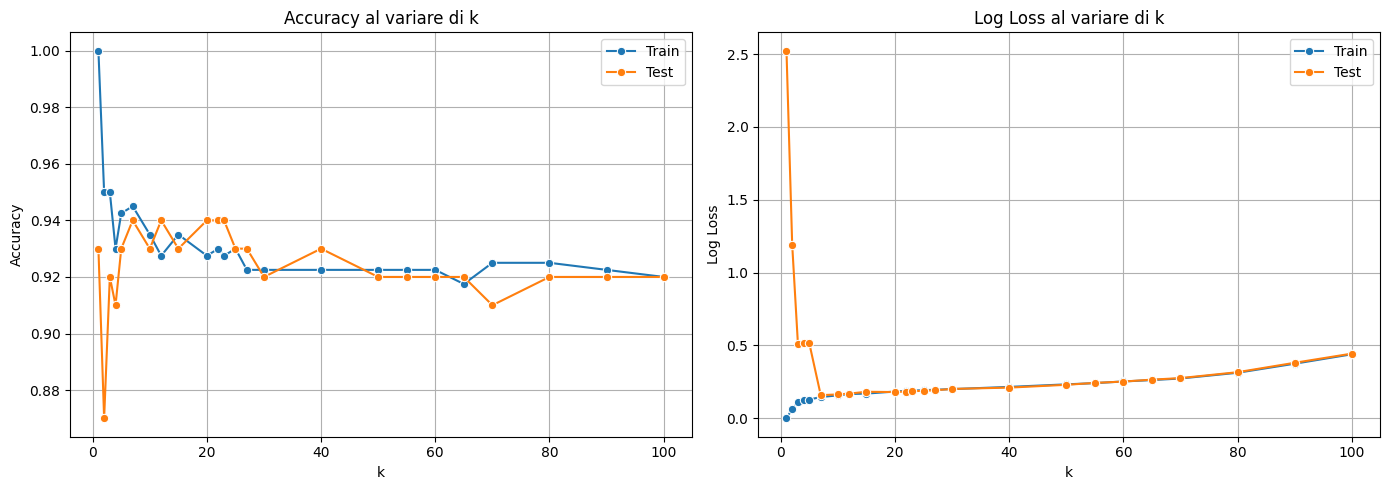

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=results_df, x="k", y="accuracy_train", marker="o", label="Train")
sns.lineplot(data=results_df, x="k", y="accuracy_test", marker="o", label="Test")
plt.title("Accuracy al variare di k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.lineplot(data=results_df, x="k", y="log_loss_train", marker="o", label="Train")
sns.lineplot(data=results_df, x="k", y="log_loss_test", marker="o", label="Test")
plt.title("Log Loss al variare di k")
plt.xlabel("k")
plt.ylabel("Log Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

Grafico accuracy:
- Per valori di k più piccoli (minori di 5) l'accuracy sul training set è più alta rispetto a quella del test set, ad indicare un po' di overfitting e di incapacità a generalizzare.
- All'aumentare del valore di k il divario tra i due set di riduce e si stabilizza.

Grafico log loss:
- Il grafico della log loss conferma in sostanza le stesse tendenze.


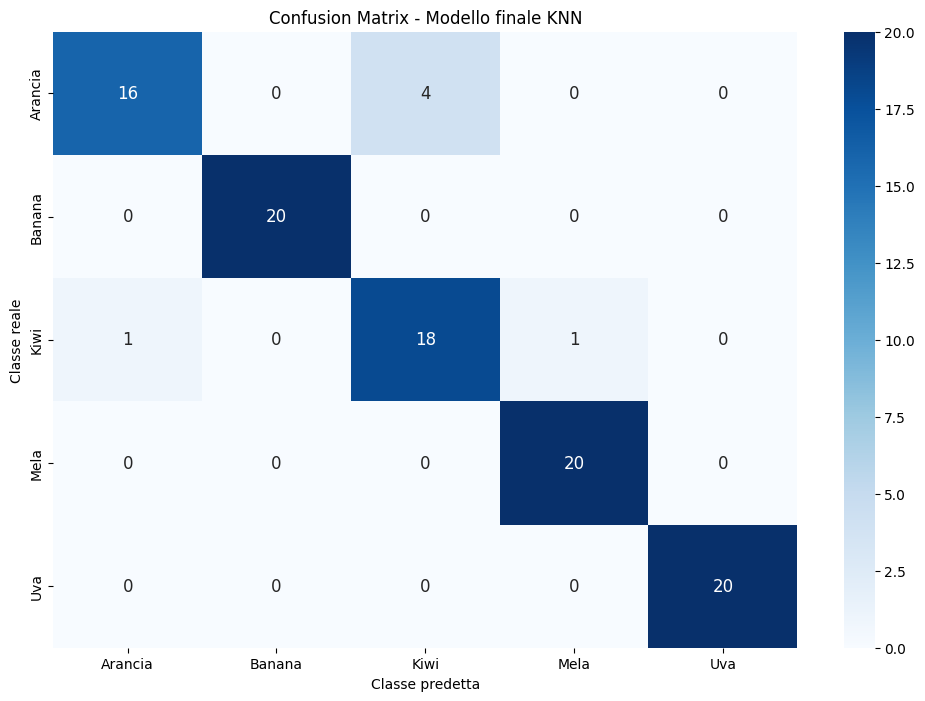

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(
  cm,
  annot=True,
  fmt="d",
  cmap="Blues",
  xticklabels=le.classes_,
  yticklabels=le.classes_,
  annot_kws={'size':12})
plt.title("Confusion Matrix - Modello finale KNN")
plt.xlabel("Classe predetta")
plt.ylabel("Classe reale")
plt.show()

- `Banana`, `Mela` e `Uva` classificate tutte correttamente.
- `Kiwi` 2 errori e `Arancia` 4 errori. Come già detto probabilmente questi due frutti hanno caratteristiche fisiche sovrapponibili.

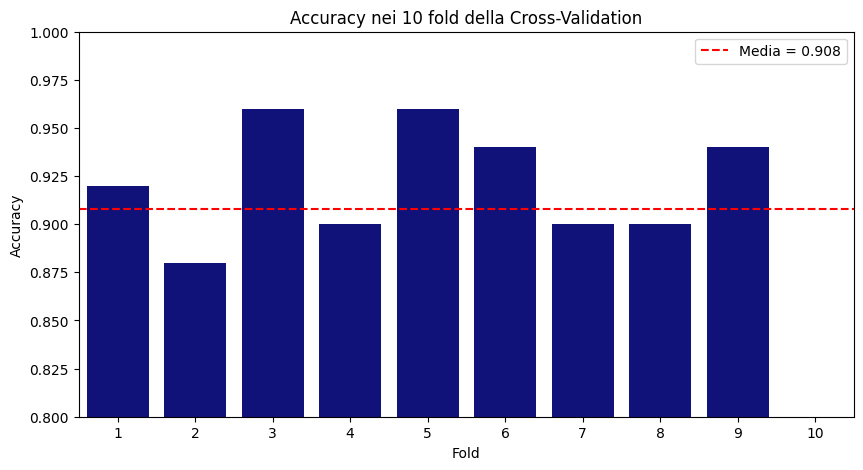

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(range(1, len(cv_scores) + 1)), y=cv_scores, color="darkblue")
plt.axhline(cv_scores.mean(), color="red", linestyle="--", label=f"Media = {cv_scores.mean():.3f}")
plt.title("Accuracy nei 10 fold della Cross-Validation")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

- La variabilità dei fold come già detto è contenuta.

In conclusione:
- È stata raggiunta un'accuracy del 94% sul test set e una media del 90% nella cross-validation con 10 fold.
- Le classi con caratteristiche fisiche più distintive sono state classificate senza errori mentre le classi con caratteristiche più sovrapposte hanno  prodotto il maggior numero di errori.

Possibili miglioramenti futuri potrebbero includere:
- Test tramite metriche di distanza alternative (Manhattan, Euclidea).
- Confronto con altri algoritmi di classificazione (SVM, Random Forest)
per valutare se KNN è effettivamente il modello più adatto a questo dataset.